In [88]:
# Importing relevant libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as ticker

# Getting directory where the notebook is located
notebook_dir = Path.cwd()

# Naviating to folder that contains datasets
data_dir = notebook_dir.parent/'dataset'

# Creating DataFrames for each file
aisles = pd.read_csv(data_dir / 'aisles.csv')
departments = pd.read_csv(data_dir / 'departments.csv')
orders = pd.read_csv(data_dir / 'orders.csv')
products = pd.read_csv(data_dir / 'products.csv')
order_products_prior = pd.read_csv(data_dir / 'order_products__prior.csv')

In [89]:
# Reviewing data structure to see what columns/files are relevant

aisles.info()
departments.info()
orders.info()
products.info()
order_products_prior.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               in

In [90]:
order_history = (pd.merge(order_products_prior, products, how='inner', on='product_id')
                 .merge(departments, how='inner', on='department_id')
                 .merge(aisles, how='inner', on='aisle_id'))
order_history = (order_history
                 .drop(columns=['aisle_id', 'department_id'], axis=1))
order_history.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,department,aisle
0,2,33120,1,1,Organic Egg Whites,dairy eggs,eggs
1,2,28985,2,1,Michigan Organic Kale,produce,fresh vegetables
2,2,9327,3,0,Garlic Powder,pantry,spices seasonings
3,2,45918,4,1,Coconut Butter,pantry,oils vinegars
4,2,30035,5,0,Natural Sweetener,pantry,baking ingredients


In [91]:
days = {0: 'Sunday', 
        1:'Monday', 
        2:'Tuesday', 
        3:'Wednesday', 
        4:'Thursday', 
        5:'Friday', 
        6:'Saturday'}

weekend_map = {
    'Sunday': 'Weekend',
    'Monday': 'Weekday',
    'Tuesday': 'Weekday',
    'Wednesday': 'Weekday',
    'Thursday': 'Weekday',
    'Friday': 'Weekday',
    'Saturday': 'Weekend'}

orders['day_name'] = orders['order_dow'].map(days)
orders['day_type'] = orders['day_name'].map(weekend_map)
orders_final = orders[orders['eval_set'].isin(['prior', 'train'])]
orders_final.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,day_name,day_type
0,2539329,1,prior,1,2,8,NaN,Tuesday,Weekday
1,2398795,1,prior,2,3,7,15.0,Wednesday,Weekday
2,473747,1,prior,3,3,12,21.0,Wednesday,Weekday
3,2254736,1,prior,4,4,7,29.0,Thursday,Weekday
4,431534,1,prior,5,4,15,28.0,Thursday,Weekday


In [92]:
full_history = pd.merge(order_history, orders_final, how='inner', on='order_id')
full_history.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,department,aisle,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,day_name,day_type
0,2,33120,1,1,Organic Egg Whites,dairy eggs,eggs,202279,prior,3,5,9,8.0,Friday,Weekday
1,2,28985,2,1,Michigan Organic Kale,produce,fresh vegetables,202279,prior,3,5,9,8.0,Friday,Weekday
2,2,9327,3,0,Garlic Powder,pantry,spices seasonings,202279,prior,3,5,9,8.0,Friday,Weekday
3,2,45918,4,1,Coconut Butter,pantry,oils vinegars,202279,prior,3,5,9,8.0,Friday,Weekday
4,2,30035,5,0,Natural Sweetener,pantry,baking ingredients,202279,prior,3,5,9,8.0,Friday,Weekday


**Data Cleaning Steps**

- Only one file containued blank values, which was the orders file
    - This is possible though given that the every users' first order will not have days since the prior order
- Merged the files into three primary datasets
    - **order_history**: Breaks down items that were in each order along with the product, department, and aisle
    - **orders_final**: Provides user IDs and order details for each order
        - This dataset was initially for machine learning purposes so am only filtering for the prior and train values and not the test values which would have been used to train the data model
    - **full_history**: Joins together order_history and orders_final

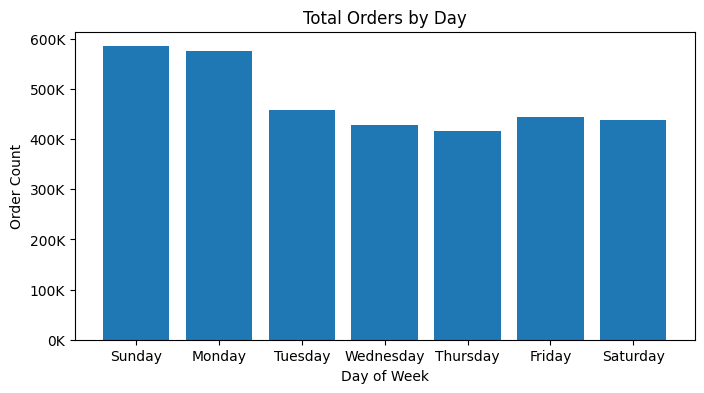

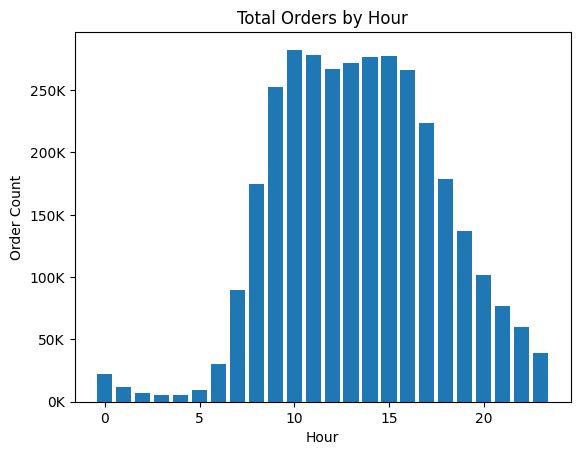

In [ ]:
orders_by_day = (orders_final.groupby(['order_dow', 'day_name'])['order_id'] # Grouping order_id by day
                 .count() # Count of order_id
                 .reset_index(name='order_count') # Cleaning up DataFrame
                 .sort_values(by='order_dow', ascending=True)) # Sort on day of week number ascending


# Plotting orders by day
plt.figure(figsize=(8, 4))
plt.bar(orders_by_day.day_name, orders_by_day.order_count)
plt.xlabel('Day of Week')
plt.ylabel('Order Count')
plt.title('Total Orders by Day')
ax = plt.gca()  
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

plt.show()
orders_by_day

orders_by_hour = (orders_final.groupby(['order_hour_of_day'])['order_id'] # Grouping order_id by hour
                 .count() # Count of order_id
                 .reset_index(name='order_count') # Cleaning up DataFrame
                 .sort_values(by='order_hour_of_day', ascending=True)
                 ) # Sort on day of week number ascending

# Plotting orders by hour

plt.bar(orders_by_hour.order_hour_of_day, orders_by_hour.order_count)
plt.xlabel('Hour')
plt.ylabel('Order Count')
plt.title('Total Orders by Hour')
ax = plt.gca()  
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

plt.show()

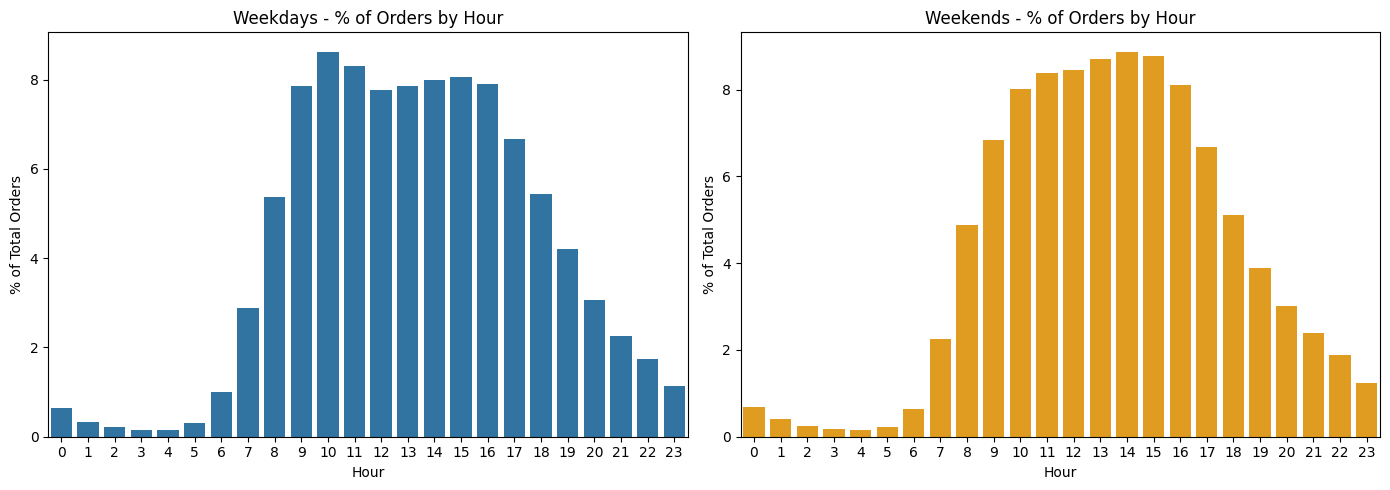

In [ ]:
# DataFrames aggregating weekday and weekend ourder counts
weekdays = (orders_final[orders_final['day_type'] == 'Weekday']
            .groupby(['order_hour_of_day'])['order_id']
            .count()
            .reset_index(name='order_count'))
weekdays['percent_of_total'] = round((weekdays['order_count'] / (weekdays['order_count'].sum()))*100, 2) # Adding in calculation to see what % of total orders each hour makes up
weekdays['avg_order_per_day'] = round(weekdays['order_count'] / 5) # Adding in calculation to see what average order volume is on a weekday vs. weekend for any given hour

weekends = (orders_final[orders_final['day_type'] == 'Weekend']
            .groupby(['order_hour_of_day'])['order_id']
            .count()
            .reset_index(name='order_count'))
weekends['percent_of_total'] = round((weekends['order_count'] / (weekends['order_count'].sum()))*100, 2)
weekends['avg_order_per_day'] = round(weekends['order_count'] / 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='order_hour_of_day', y='percent_of_total', data=weekdays, ax=axes[0])
axes[0].set_title('Weekdays - % of Orders by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('% of Total Orders')

sns.barplot(x='order_hour_of_day', y='percent_of_total', data=weekends, ax=axes[1], color='orange')
axes[1].set_title('Weekends - % of Orders by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('% of Total Orders')

plt.tight_layout()  # Prevents labels from overlapping
plt.show()


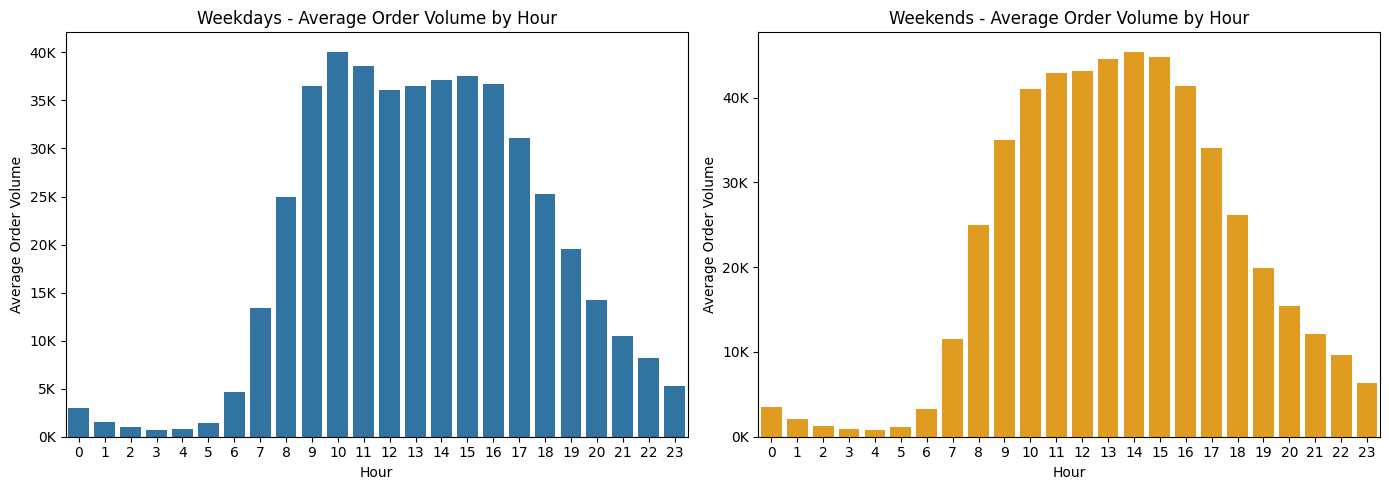

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='order_hour_of_day', y='avg_order_per_day', data=weekdays, ax=axes[0])
axes[0].set_title('Weekdays - Average Order Volume by Hour')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Average Order Volume")

sns.barplot(x='order_hour_of_day', y='avg_order_per_day', data=weekends, ax=axes[1], color='orange')
axes[1].set_title('Weekends - Average Order Volume by Hour')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Average Order Volume")

plt.tight_layout()
plt.show()

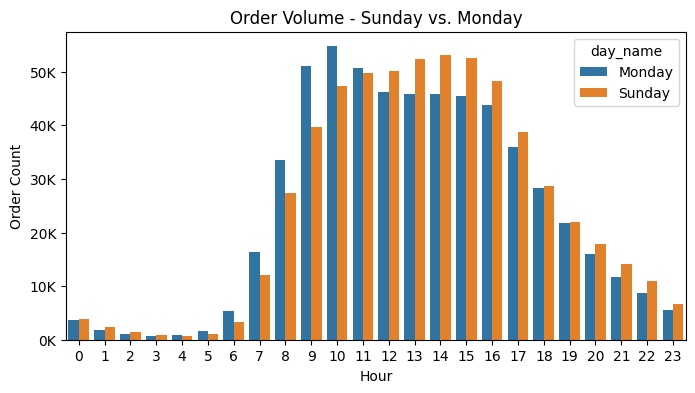

In [ ]:
# DataFrame to compare Sunday and Monday order volume trends

top_two = (orders_final[orders_final['order_dow'].isin([0,1])]
            .groupby(['day_name','order_hour_of_day'])['order_id']
            .count()
            .reset_index(name='order_count'))

plt.figure(figsize=(8, 4))
sns.barplot(data=top_two, x='order_hour_of_day', y='order_count', hue='day_name')
plt.xlabel('Hour')
plt.ylabel('Order Count')
plt.title('Order Volume - Sunday vs. Monday')
ax = plt.gca()  
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

**Weekends vs. Weekdays Ordering Dynamics**

*Order Volume*
- Sundays and Mondays are the highest order volume days with Sunday seeing slightly more orders
- As the week progresses, orders taper off until Friday where there is a slight pick up prior to the peak days
    - Sunday is likely the most popular day for orders as people will be shopping for groceries for the week
        - Comparing hourly trends on Sunday to Monday, the peak ordering times for 9AM to 11AM

*Ordering Time*
- In order to normalize for there being more weekdays than weekends, the average order volume per hour and percent of orders by hour are used to compare both day types
    - Weekdays generally see their peak ordering times somewhere between 9AM to 11AM whereas peak times on weekends are between 1PM and 3PM
        - On weekdays, there is a slight bump around 3PM which could be from grocers looking to get ingredients to prep for dinner
    - The largest % of orders for both types of days also follows suit when looking at it from an hourly perspective
        - A possibility for this difference could be potentially be people working from home and planning lunch might place grocery orders in the morning
        - On the weekends, people may be getting a later start to their day which consequently would push back peak ordering times
- Focusing in on the two peak days (Sunday and Monday), total order volume follows the same trends outlined above

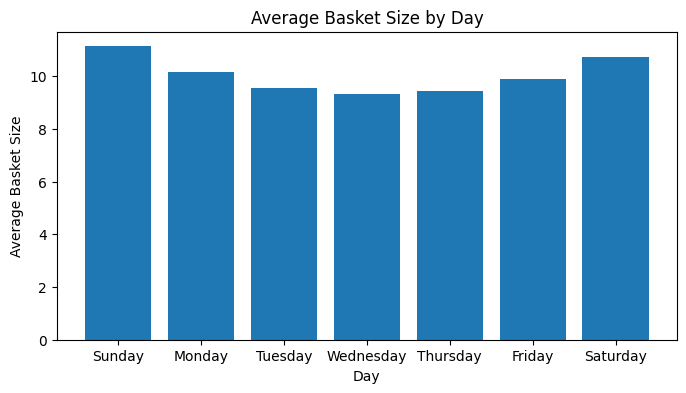

In [167]:
# Starting DataFrame to analyze basket size
basket_size_raw = (full_history
                   .groupby(['order_id', 'order_hour_of_day', 'order_dow', 'day_name','day_type'])
                   ['product_id'].nunique()
                   .reset_index(name='basket_size'))

# display(basket_size_raw['basket_size'].mean()) # average basket size across the dataset
# display(basket_size_raw['basket_size'].std()) # standard deviation for basket size
# display(basket_size_raw['basket_size'].median()) # median basket size

avg_basket_size_by_day = (basket_size_raw
                          .groupby(['order_dow', 'day_name'])
                          ['basket_size'].mean()
                          .reset_index(name='avg_basket_size')
                          .sort_values(by='order_dow', ascending=True))

plt.figure(figsize=(8, 4))
plt.bar(data=avg_basket_size_by_day, x='day_name', height='avg_basket_size')
plt.xlabel('Day')
plt.ylabel('Average Basket Size')
plt.title('Average Basket Size by Day')
plt.show()

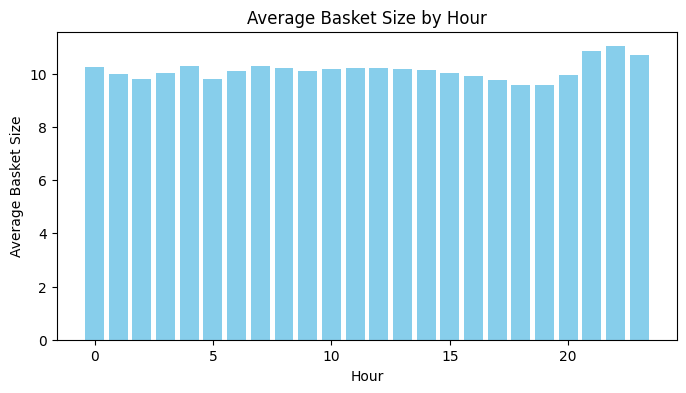

In [166]:
avg_basket_size_by_hour = (basket_size_raw
                           .groupby(['order_hour_of_day'])
                           ['basket_size'].mean()
                           .reset_index(name='avg_basket_size')
                           .sort_values(by='order_hour_of_day', ascending=True))

plt.figure(figsize=(8, 4))
plt.bar(data=avg_basket_size_by_hour, x='order_hour_of_day', height='avg_basket_size', color='skyblue')
plt.xlabel('Hour')
plt.ylabel('Average Basket Size')
plt.title('Average Basket Size by Hour')
plt.show()

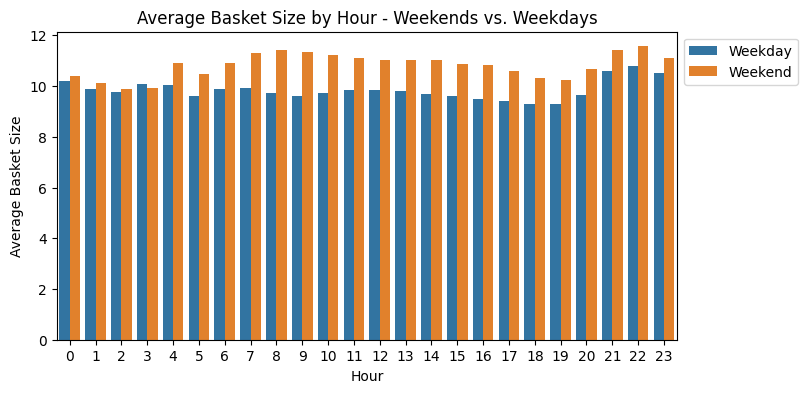

In [180]:
avg_basket_size_by_hour_daytype = (basket_size_raw
                           .groupby(['order_hour_of_day', 'day_type'])
                           ['basket_size'].mean()
                           .reset_index(name='avg_basket_size')
                           .sort_values(by='order_hour_of_day', ascending=True))

avg_basket_size_by_hour_daytype

plt.figure(figsize=(8, 4))
sns.barplot(data=avg_basket_size_by_hour_daytype, x='order_hour_of_day', y='avg_basket_size', hue='day_type')
plt.xlabel('Hour')
plt.ylabel('Average Basket Size')
plt.title('Average Basket Size by Hour - Weekends vs. Weekdays')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

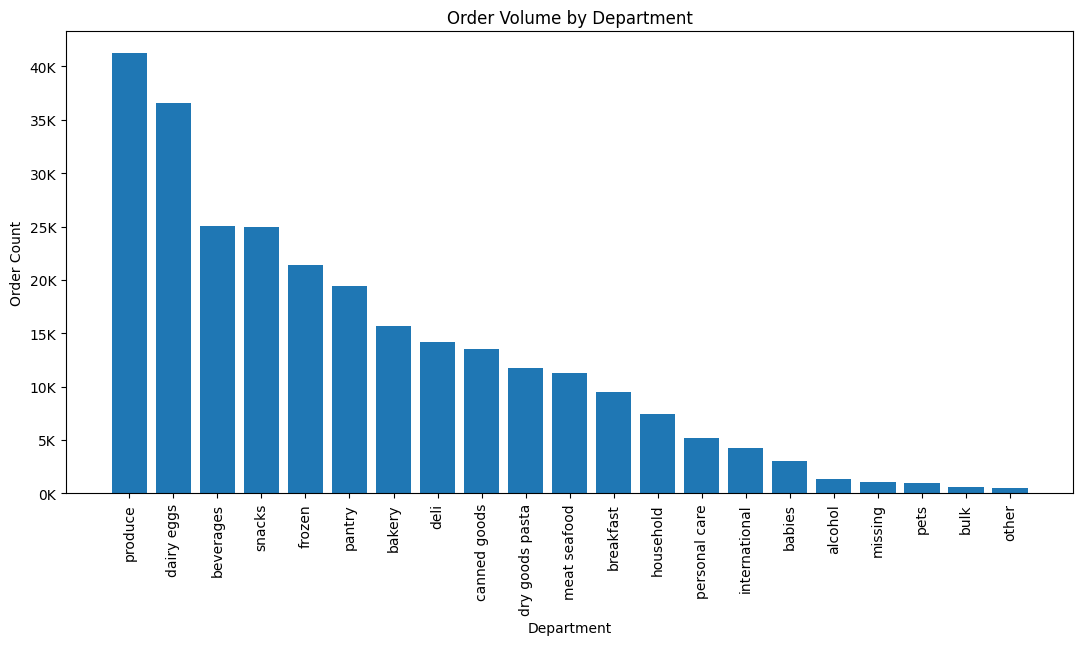

In [206]:
full_history.head()

orders_by_department = (full_history
                        .groupby(['department', 'order_dow', 'day_name', 'order_hour_of_day','day_type'])
                        ['order_id'].nunique()
                        .reset_index(name='order_count')
                        .sort_values(by='order_count', ascending=False))

plt.figure(figsize=(13, 6))
plt.bar(data=orders_by_department, x='department', height='order_count')
plt.xlabel('Department')
plt.xticks(rotation=90)
plt.ylabel('Order Count')
ax = plt.gca()  
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
plt.title('Order Volume by Department')
plt.show()

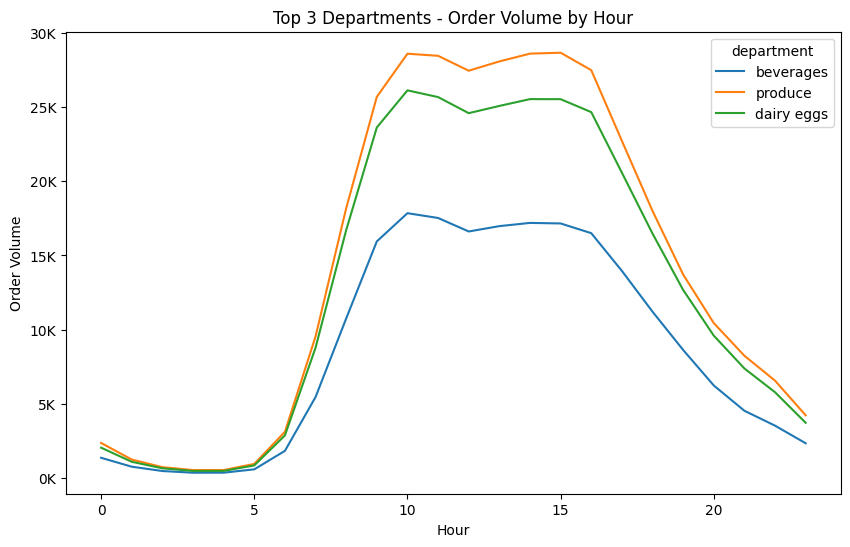

In [ ]:
top_three_departments = ['produce', 'dairy eggs', 'beverages']

top_three = orders_by_department[orders_by_department['department'].isin(top_three_departments)]
top_three_grouped = (top_three
                     .groupby(['department', 'order_hour_of_day', 'day_name'])
                     ['order_count'].sum()
                     .reset_index()
                     .sort_values(by='order_hour_of_day', ascending=True))

plt.figure(figsize=(10, 6))
sns.lineplot(data=top_three_grouped, hue='department', x='order_hour_of_day', y= 'order_count', errorbar=None)
plt.xlabel('Hour')
plt.ylabel('Order Volume')
plt.title('Top 3 Departments - Order Volume by Hour')
ax = plt.gca()  
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))
plt.show()